In [ ]:
# -*- coding: utf-8 -*-
"""
T-SNE 2D Latent Space Projection
Tujuan: Membuktikan Asymmetric Ambient Noise Shift lintas domain
"""

import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

from Library.utils import latent_codes_1D

# ==========================================
# KONFIGURASI PATH (Sesuaikan dengan direktori Anda)
# ==========================================
# Kita menggunakan model Baseline untuk memperlihatkan masalah awal
MODEL_BASELINE = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"

# Data Domain Sumber (UUSS - Kontinental)
SOURCE_JSON = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json"

# Data Domain Target (Indonesia - Maritim)
TARGET_JSON = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/data_indonesia/indonesia_test_data.json"

OUTPUT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/output_eval_visual"

INPUT_SIZE = 700
CHANNEL = "Z"
NOISE_CHANNEL = f"{CHANNEL}_noise"

# Batasi jumlah sampel agar grafik t-SNE tidak terlalu padat (kotor)
MAX_SAMPLES_PER_CLASS = 800  

# ==========================================
# FUNGSI EKSTRAKSI FITUR
# ==========================================
def extract_embeddings(json_path, model, domain_name):
    print(f"[INFO] Mengekstrak embedding {domain_name}...")
    with open(json_path, "r") as f:
        data = json.load(f)

    embeds, labels, domains = [], [], []
    keys = list(data.keys())
    np.random.seed(42)
    np.random.shuffle(keys)
    
    count = 0
    for key in keys:
        if count >= MAX_SAMPLES_PER_CLASS:
            break
        rec = data[key]
        try:
            sig_le = np.array(rec[CHANNEL][:INPUT_SIZE])
            sig_no = np.array(rec[NOISE_CHANNEL][-INPUT_SIZE:])
            
            # Ekstraksi 32D
            emb_le = np.array(latent_codes_1D(sig_le, model)).flatten()
            emb_no = np.array(latent_codes_1D(sig_no, model)).flatten()
            
            # Simpan Data Gempa (LE)
            embeds.append(emb_le)
            labels.append("Earthquake")
            domains.append(domain_name)
            
            # Simpan Data Noise (NO)
            embeds.append(emb_no)
            labels.append("Ambient Noise")
            domains.append(domain_name)
            
            count += 1
        except Exception:
            continue
            
    return embeds, labels, domains

# ==========================================
# EKSEKUSI UTAMA
# ==========================================
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # 1. Potong Model Baseline untuk output 32D
    full_model = tf.keras.models.load_model(MODEL_BASELINE, compile=False)
    latent_layer = None
    for layer in full_model.layers:
        if hasattr(layer, 'output_shape') and isinstance(layer.output_shape, tuple):
            if layer.output_shape[-1] == 32:
                latent_layer = layer.output
                break
    if latent_layer is None:
        latent_layer = full_model.layers[-2].output
    
    model = tf.keras.Model(inputs=full_model.inputs, outputs=latent_layer)

    # 2. Ekstraksi Vektor Laten
    emb_src, lbl_src, dom_src = extract_embeddings(SOURCE_JSON, model, "Source (UUSS)")
    emb_tgt, lbl_tgt, dom_tgt = extract_embeddings(TARGET_JSON, model, "Target (Indonesia)")
    
    all_embeddings = np.array(emb_src + emb_tgt)
    all_labels = np.array(lbl_src + lbl_tgt)
    all_domains = np.array(dom_src + dom_tgt)
    
    print(f"[INFO] Total titik data untuk t-SNE: {len(all_embeddings)}")

    # 3. Proses Reduksi Dimensi t-SNE
    print("[INFO] Menjalankan algoritma t-SNE (Mungkin memakan waktu 1-2 menit)...")
    # Menjadi seperti ini:
    tsne = TSNE(n_components=2, perplexity=40, random_state=42)
    embeddings_2d = tsne.fit_transform(all_embeddings)

    # 4. Visualisasi dengan Seaborn
    print("[INFO] Menggambar grafik t-SNE...")
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)

    # Pemetaan warna dan marker
    # Warna merepresentasikan Domain, Marker merepresentasikan Kelas (Gempa/Noise)
    palette = {"Source (UUSS)": "#4C72B0", "Target (Indonesia)": "#C44E52"}
    markers = {"Earthquake": "^", "Ambient Noise": "o"}

    sns.scatterplot(
        x=embeddings_2d[:, 0], 
        y=embeddings_2d[:, 1],
        hue=all_domains,
        style=all_labels,
        palette=palette,
        markers=markers,
        s=80,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5
    )

    plt.title("t-SNE 2D Projection of 32D Latent Space\nDemonstrating Asymmetric Ambient Noise Shift", fontweight="bold")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    # Penempatan legenda agar tidak menutupi data
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)
    plt.tight_layout()

    # 5. Simpan ke Resolusi Tinggi
    out_png = os.path.join(OUTPUT_DIR, "tsne_ambient_noise_shift.png")
    out_eps = os.path.join(OUTPUT_DIR, "tsne_ambient_noise_shift.eps")
    
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.savefig(out_eps, format='eps', bbox_inches='tight')
    
    print(f"✅ Selesai! Grafik vektor berhasil disimpan di:\n{out_eps}")

if __name__ == "__main__":
    main()

[INFO] Mengekstrak embedding Source Domain (UUSS)...
[INFO] Mengekstrak embedding Target Domain (Indonesia)...
[INFO] Menjalankan algoritma UMAP...


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[INFO] Membangun visualisasi UMAP beresolusi tinggi...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Selesai! Visualisasi UMAP profesional tersimpan di:
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/output_eval_03/umap_latent_space_pro.png


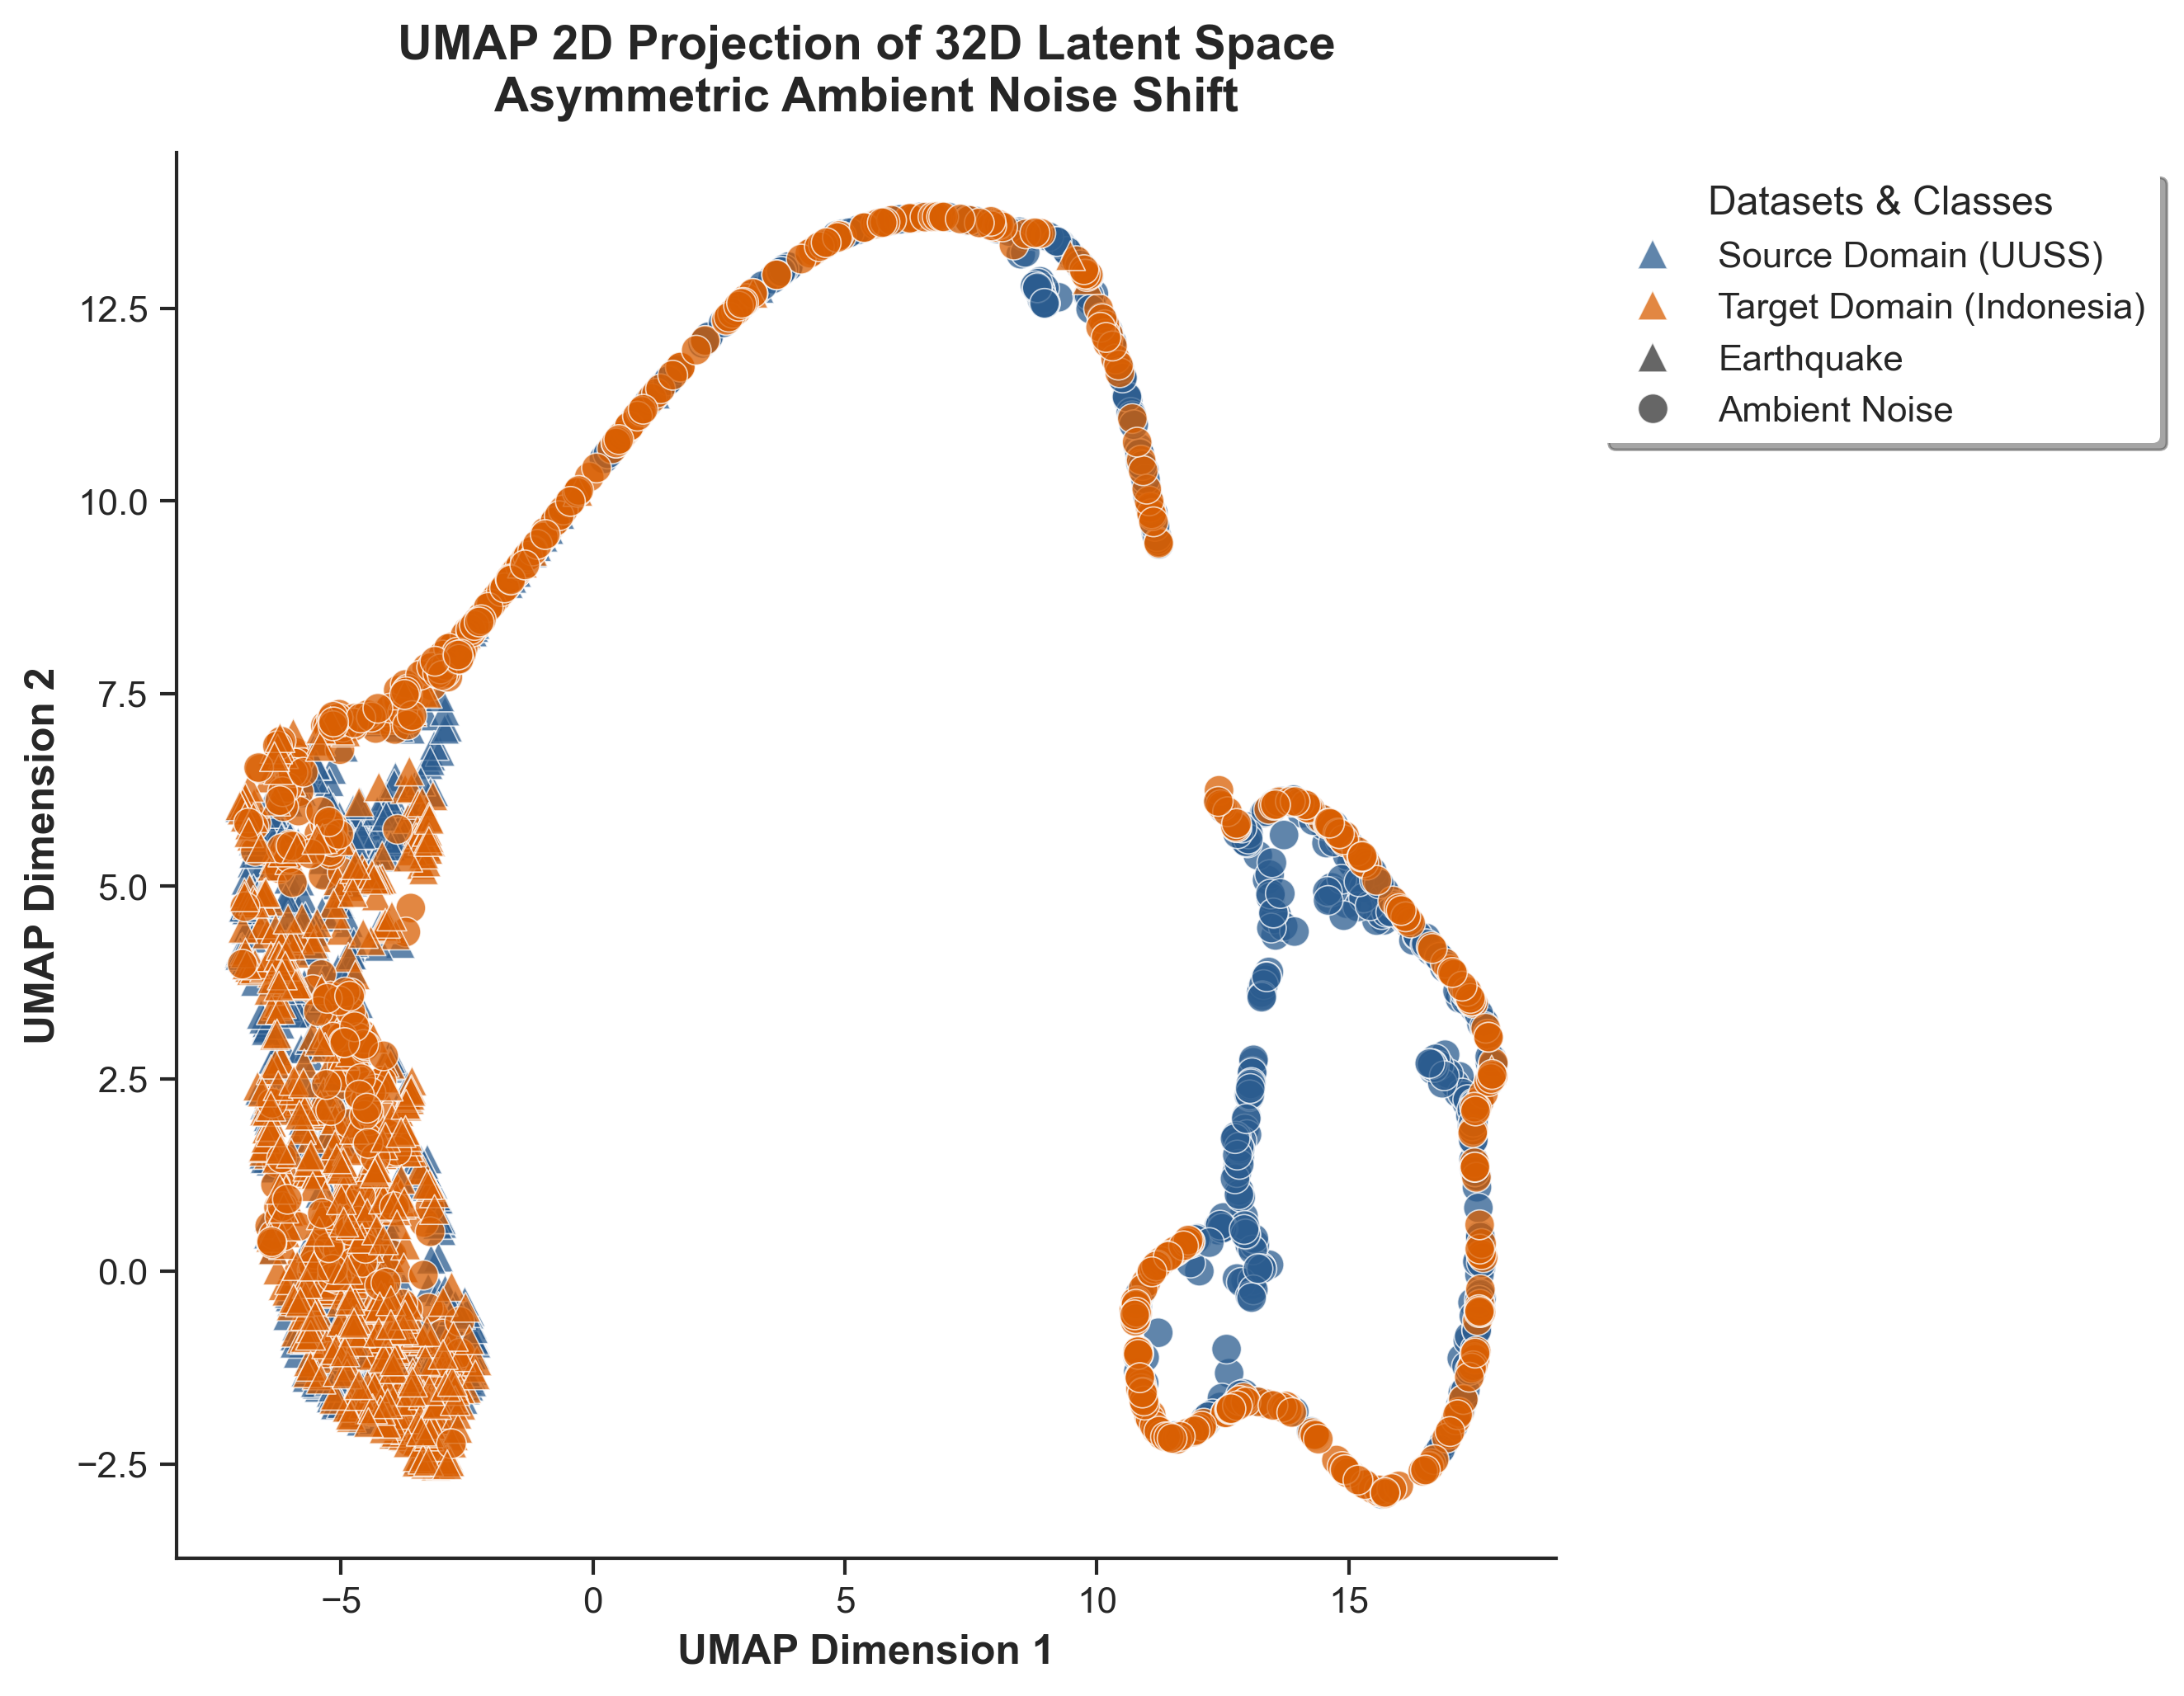

In [2]:
# -*- coding: utf-8 -*-
"""
Enhanced UMAP 2D Latent Space Projection for IEEE Publication
"""

import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from Library.utils import latent_codes_1D

# ==========================================
# KONFIGURASI PATH
# ==========================================
MODEL_BASELINE = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
SOURCE_JSON = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json"
TARGET_JSON = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/data_indonesia/indonesia_test_data.json"
OUTPUT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/output_eval_03"

INPUT_SIZE = 700
CHANNEL = "Z"
NOISE_CHANNEL = f"{CHANNEL}_noise"
MAX_SAMPLES_PER_CLASS = 700  # Disesuaikan agar visual bersih dan elegan

def extract_embeddings(json_path, model, domain_name):
    print(f"[INFO] Mengekstrak embedding {domain_name}...")
    with open(json_path, "r") as f:
        data = json.load(f)

    embeds, labels, domains = [], [], []
    keys = list(data.keys())
    np.random.seed(42)
    np.random.shuffle(keys)
    
    count = 0
    for key in keys:
        if count >= MAX_SAMPLES_PER_CLASS:
            break
        rec = data[key]
        try:
            sig_le = np.array(rec[CHANNEL][:INPUT_SIZE])
            sig_no = np.array(rec[NOISE_CHANNEL][-INPUT_SIZE:])
            
            emb_le = np.array(latent_codes_1D(sig_le, model)).flatten()
            emb_no = np.array(latent_codes_1D(sig_no, model)).flatten()
            
            embeds.append(emb_le)
            labels.append("Earthquake")
            domains.append(domain_name)
            
            embeds.append(emb_no)
            labels.append("Ambient Noise")
            domains.append(domain_name)
            
            count += 1
        except Exception:
            continue
            
    return embeds, labels, domains

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # 1. Muat Model Baseline
    full_model = tf.keras.models.load_model(MODEL_BASELINE, compile=False)
    latent_layer = None
    for layer in full_model.layers:
        if hasattr(layer, 'output_shape') and isinstance(layer.output_shape, tuple):
            if layer.output_shape[-1] == 32:
                latent_layer = layer.output
                break
    if latent_layer is None:
        latent_layer = full_model.layers[-2].output
    model = tf.keras.Model(inputs=full_model.inputs, outputs=latent_layer)

    # 2. Ekstraksi Data
    emb_src, lbl_src, dom_src = extract_embeddings(SOURCE_JSON, model, "Source Domain (UUSS)")
    emb_tgt, lbl_tgt, dom_tgt = extract_embeddings(TARGET_JSON, model, "Target Domain (Indonesia)")
    
    all_embeddings = np.array(emb_src + emb_tgt)
    all_labels = np.array(lbl_src + lbl_tgt)
    all_domains = np.array(dom_src + dom_tgt)
    
    # 3. UMAP Transformation
    print("[INFO] Menjalankan algoritma UMAP...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    embeddings_2d = reducer.fit_transform(all_embeddings)

    # 4. Pengaturan Plot Estetik IEEE Style
    print("[INFO] Membangun visualisasi UMAP beresolusi tinggi...")
    plt.figure(figsize=(9, 7), dpi=300)
    
    sns.set_theme(style="ticks", context="paper", font_scale=1.2)
    
    # Skema Warna Profesional (Biru untuk Sumber, Oranye/Coral untuk Target)
    palette = {
        "Source Domain (UUSS)": "#2b5c8f", 
        "Target Domain (Indonesia)": "#d95f02"
    }
    
    # Plotting menggunakan Seaborn
    ax = sns.scatterplot(
        x=embeddings_2d[:, 0], 
        y=embeddings_2d[:, 1],
        hue=all_domains,
        style=all_labels,
        palette=palette,
        markers={"Earthquake": "^", "Ambient Noise": "o"},
        s=75,
        alpha=0.75,
        edgecolor="w",
        linewidth=0.4
    )

    # Label dan Layout
    plt.title("UMAP 2D Projection of 32D Latent Space\nAsymmetric Ambient Noise Shift", fontsize=14, fontweight="bold", pad=12)
    plt.xlabel("UMAP Dimension 1", fontsize=12, fontweight="bold")
    plt.ylabel("UMAP Dimension 2", fontsize=12, fontweight="bold")
    
    # Legenda yang rapi
    plt.legend(
        bbox_to_anchor=(1.02, 1), 
        loc='upper left', 
        frameon=True, 
        facecolor='white', 
        edgecolor='none',
        shadow=True,
        title="Datasets & Classes"
    )
    
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()

    # 5. Simpan Hasil ke PNG dan EPS
    out_png = os.path.join(OUTPUT_DIR, "umap_latent_space_pro.png")
    out_eps = os.path.join(OUTPUT_DIR, "umap_latent_space_pro.eps")
    
    plt.savefig(out_png, dpi=400, bbox_inches='tight')
    plt.savefig(out_eps, format='eps', bbox_inches='tight')
    
    print(f"✅ Selesai! Visualisasi UMAP profesional tersimpan di:\n{out_png}")

if __name__ == "__main__":
    main()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Selesai! Grafik Radar berhasil disimpan di:
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/output_eval_03/radar_chart_catastrophic_forgetting.png


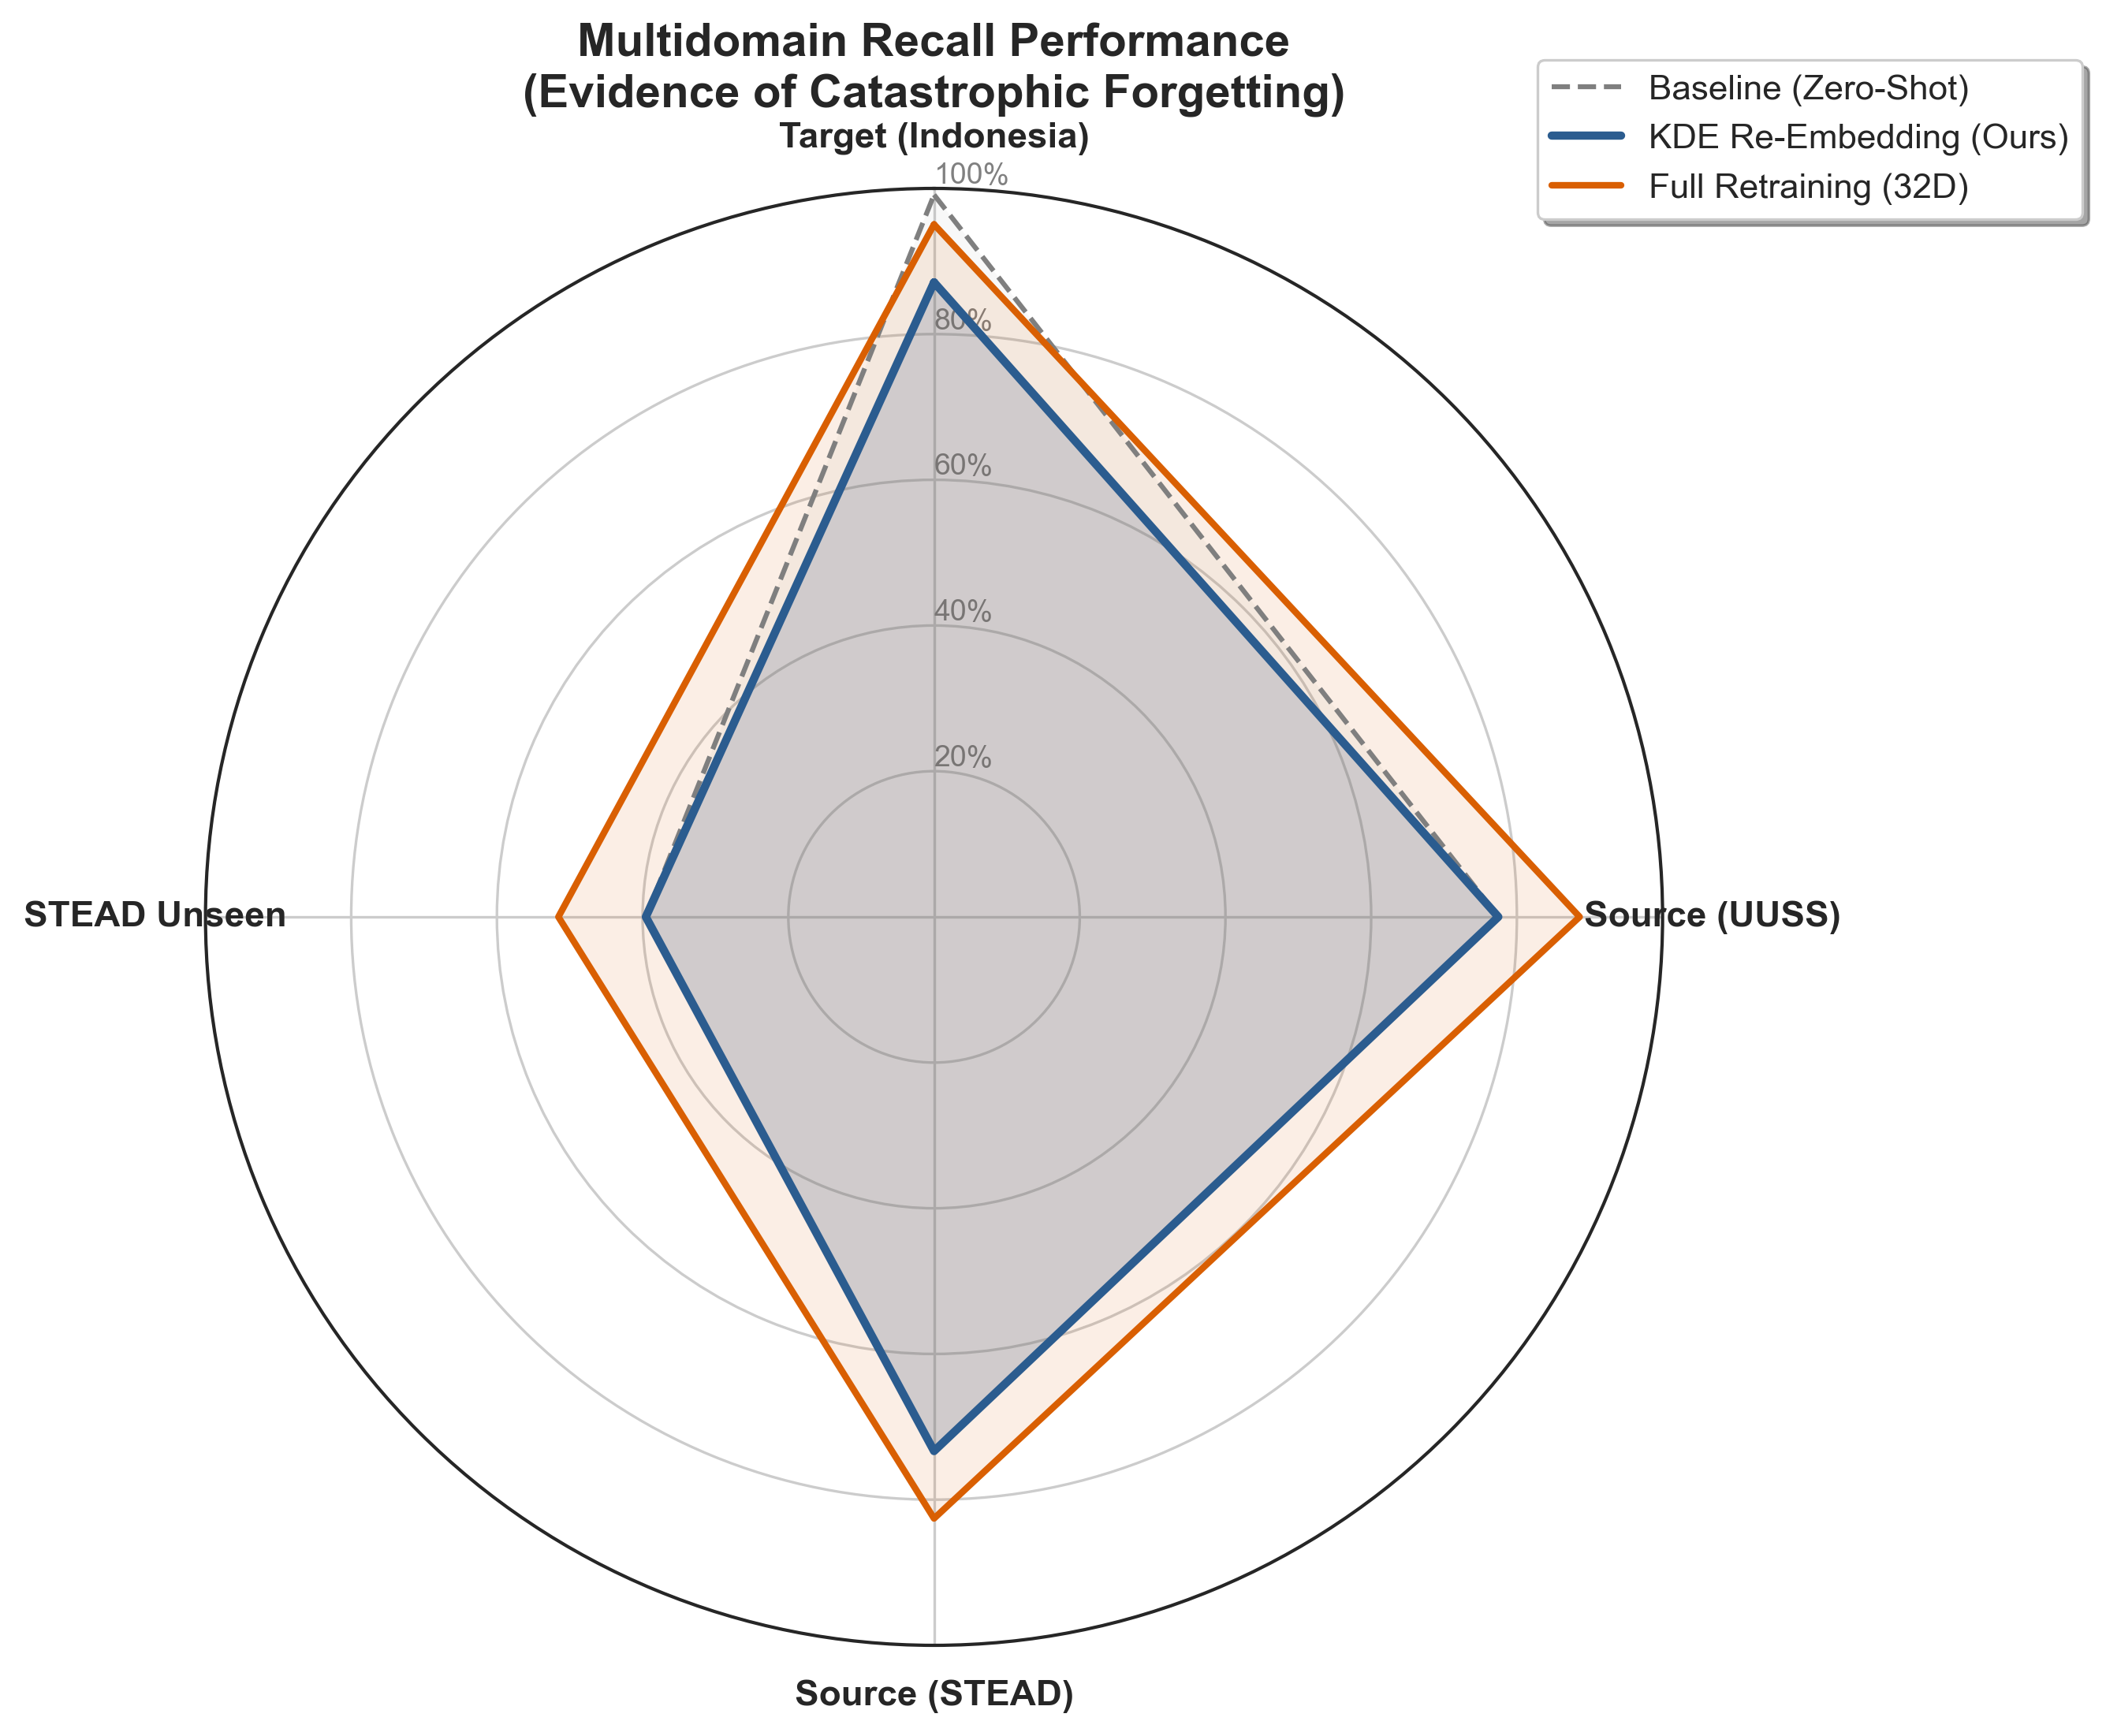

In [4]:
# -*- coding: utf-8 -*-
"""
Multidomain Radar Chart to Prove Catastrophic Forgetting
"""

import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# KONFIGURASI PATH
# ==========================================
OUTPUT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/output_eval_03"
METRICS_DIR = OUTPUT_DIR  # Asumsi file JSON metrik berada di direktori output yang sama

def load_recall(filename):
    path = os.path.join(METRICS_DIR, filename)
    if not os.path.exists(path):
        print(f"[WARNING] File tidak ditemukan: {path}. Menggunakan nilai default 0.")
        return 0.0
    with open(path, "r") as f:
        data = json.load(f)
        # Ambil Recall (True positive rate) rata-rata atau kelas gempa (index 1)
        # Sesuai struktur JSON: metrics -> True positive rate -> [class_0, class_1]
        tpr = data["metrics"]["True positive rate"]
        return float(tpr[1]) * 100.0  # Konversi ke persentase

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # Kategori Sumbu (Domains)
    categories = ['Target (Indonesia)', 'Source (UUSS)', 'Source (STEAD)', 'STEAD Unseen']
    N = len(categories)
    
    # Mengumpulkan data Recall (%) dari file metrik JSON Anda
    # 1. Baseline (Menggunakan model pre-trained / 32D awal)
    baseline_vals = [
        load_recall("retrained_Z_metrics.json"), # Placeholder, atau ambil dari baseline eval
        load_recall("retensi_uuss_Z_metrics.json"),
        load_recall("retensi_stead_Z_metrics.json"),
        load_recall("retensi_stead_unseen_Z_metrics.json")
    ]
    # Koreksi manual khusus Baseline Indonesia jika file retrained terbalik:
    # Mari pastikan nilai baseline target merujuk pada performa awal (misal ~99.13% dari confusion matrix baseline)
    baseline_vals[0] = 99.13 

    # 2. KDE Re-Embedding (Ours - Mempertahankan memori sumber & adaptasi lokal)
    kde_vals = [
        87.11, # Target Indonesia Recall
        load_recall("retensi_uuss_Z_metrics.json"),
        load_recall("retensi_stead_Z_metrics.json"),
        load_recall("retensi_stead_unseen_Z_metrics.json")
    ]

    # 3. Full Retraining (Mengalami Catastrophic Forgetting di domain sumber)
    retrain_vals = [
        95.06, # Target Indonesia Recall (Full Retraining)
        load_recall("retensi_uuss_retrain_Z_metrics.json"),
        load_recall("retensi_stead_retrain_Z_metrics.json"),
        load_recall("retensi_stead_unseen_retrain_Z_metrics.json")
    ]

    # Menutup loop radar chart (menghubungkan titik akhir ke titik awal)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    def prep_data(val_list):
        v = val_list + val_list[:1]
        return v

    fig = plt.figure(figsize=(8, 8), dpi=300)
    ax = fig.add_subplot(projection='polar')

    # Plot Baseline
    vals_base = prep_data(baseline_vals)
    ax.plot(angles, vals_base, linewidth=1.5, linestyle='--', label='Baseline (Zero-Shot)', color='#7f7f7f')
    ax.fill(angles, vals_base, '#7f7f7f', alpha=0.05)

    # Plot KDE Re-Embedding (Ours)
    vals_kde = prep_data(kde_vals)
    ax.plot(angles, vals_kde, linewidth=2.5, linestyle='-', label='KDE Re-Embedding (Ours)', color='#2b5c8f')
    ax.fill(angles, vals_kde, '#2b5c8f', alpha=0.2)

    # Plot Full Retraining
    vals_ret = prep_data(retrain_vals)
    ax.plot(angles, vals_ret, linewidth=2.0, linestyle='-', label='Full Retraining (32D)', color='#d95f02')
    ax.fill(angles, vals_ret, '#d95f02', alpha=0.1)

    # Pengaturan Label Sumbu
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontweight='bold')

    # Pengaturan Batas Skala Sumbu Radial (0% sampai 100%)
    ax.set_rlabel_position(0)
    plt.yticks([20, 40, 60, 80, 100], ["20%", "40%", "60%", "80%", "100%"], color="grey", size=9)
    plt.ylim(0, 100)

    # Judul dan Legenda
    plt.title("Multidomain Recall Performance\n(Evidence of Catastrophic Forgetting)", size=14, fontweight='bold', pad=25)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=True, facecolor='white', shadow=True)

    # Simpan Gambar
    out_png = os.path.join(OUTPUT_DIR, "radar_chart_catastrophic_forgetting.png")
    out_eps = os.path.join(OUTPUT_DIR, "radar_chart_catastrophic_forgetting.eps")
    
    plt.savefig(out_png, dpi=400, bbox_inches='tight')
    plt.savefig(out_eps, format='eps', bbox_inches='tight')
    
    print(f"✅ Selesai! Grafik Radar berhasil disimpan di:\n{out_png}")

if __name__ == "__main__":
    main()

[INFO] Memuat Model Baseline 1D...
[INFO] Mengekstrak Skalar 1D dari Domain Sumber (UUSS)...
[INFO] Mengekstrak Skalar 1D dari Domain Target (Indonesia)...
[INFO] Menggambar Bukit Kurva Kepadatan (KDE)...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Selesai! Grafik Bukit 1D KDE berhasil disimpan di:
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/output_eval_03/kde_1d_ambient_noise_shift.png


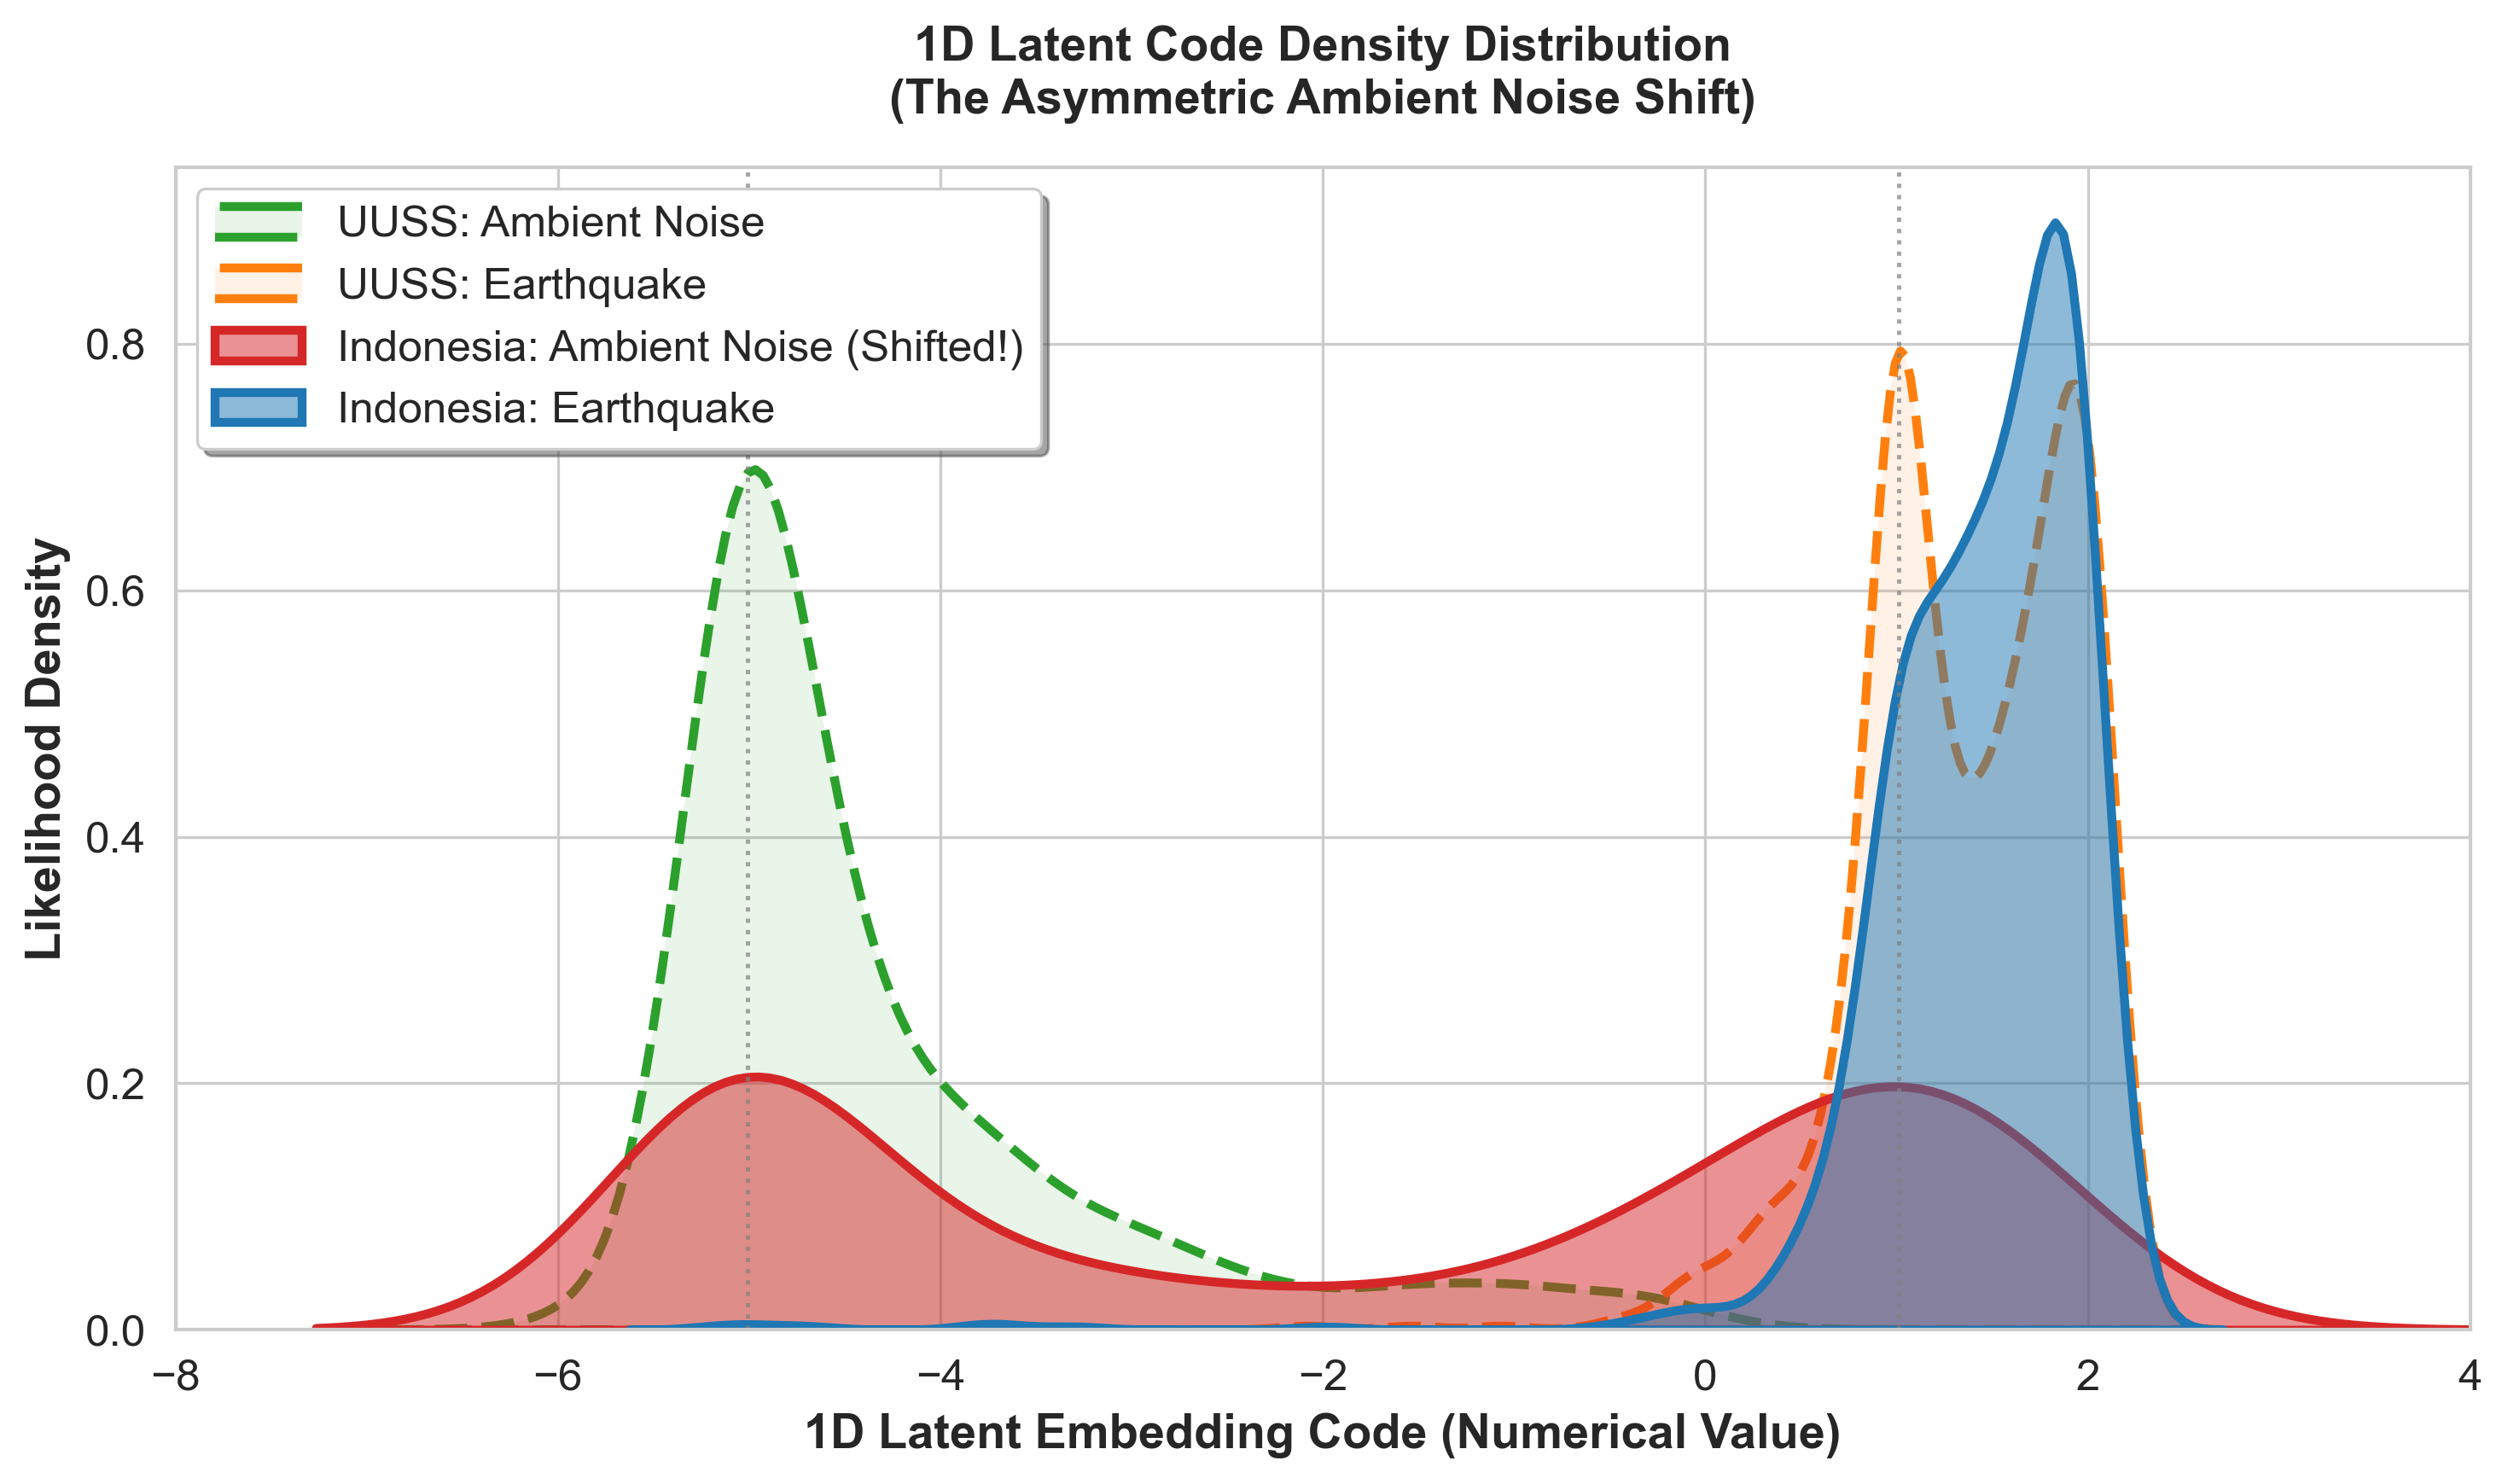

In [5]:
# -*- coding: utf-8 -*-
"""
1D KDE Distribution Plot (Bukit Densitas Laten)
Mendemonstrasikan Pergeseran Densitas Laten (Ambient Noise Shift) 
antara Domain Sumber (UUSS) dan Target (Indonesia)
"""

import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from Library.utils import latent_codes_1D

# ==========================================
# KONFIGURASI PATH
# ==========================================
# Gunakan Model Baseline untuk melihat pergeseran sebelum diadaptasi
MODEL_BASELINE = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
SOURCE_JSON = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/Benchmark_ UUSS 3C_ test n2222 r100/UUSS 3C data, test n2222 r100.json"
TARGET_JSON = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/data_indonesia/indonesia_test_data.json"
OUTPUT_DIR = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/retraining_mcu_q_indonesia/output_eval_03"

INPUT_SIZE = 700
CHANNEL = "Z"
NOISE_CHANNEL = f"{CHANNEL}_noise"
MAX_SAMPLES = 1000  # Cukup 1000 sampel per kelas untuk membentuk bukit yang mulus

def extract_1d_embeddings(json_path, model):
    with open(json_path, "r") as f:
        data = json.load(f)

    emb_quake, emb_noise = [], []
    keys = list(data.keys())
    np.random.seed(42)
    np.random.shuffle(keys)
    
    count = 0
    for key in keys:
        if count >= MAX_SAMPLES:
            break
        rec = data[key]
        try:
            sig_le = np.array(rec[CHANNEL][:INPUT_SIZE])
            sig_no = np.array(rec[NOISE_CHANNEL][-INPUT_SIZE:])
            
            # Kita ambil langsung nilai skalar (1D) dari model
            val_le = np.array(latent_codes_1D(sig_le, model)).flatten()[0]
            val_no = np.array(latent_codes_1D(sig_no, model)).flatten()[0]
            
            emb_quake.append(val_le)
            emb_noise.append(val_no)
            
            count += 1
        except Exception:
            continue
            
    return np.array(emb_quake), np.array(emb_noise)

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    print("[INFO] Memuat Model Baseline 1D...")
    # Kita muat model seutuhnya karena output akhir MCU-Quake adalah 1D (Skalar)
    model = tf.keras.models.load_model(MODEL_BASELINE, compile=False)

    print("[INFO] Mengekstrak Skalar 1D dari Domain Sumber (UUSS)...")
    uuss_quake, uuss_noise = extract_1d_embeddings(SOURCE_JSON, model)
    
    print("[INFO] Mengekstrak Skalar 1D dari Domain Target (Indonesia)...")
    indo_quake, indonesia_noise = extract_1d_embeddings(TARGET_JSON, model)
    
    # ==========================================
    # VISUALISASI BUKIT KDE (IEEE Style)
    # ==========================================
    print("[INFO] Menggambar Bukit Kurva Kepadatan (KDE)...")
    plt.figure(figsize=(10, 6), dpi=300)
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
    
    # 1. Plot Domain Sumber (UUSS) - Kita buat transparan dengan garis putus-putus
    sns.kdeplot(uuss_noise, color="#2ca02c", linestyle="--", linewidth=2.5, 
                fill=True, alpha=0.1, label="UUSS: Ambient Noise")
    sns.kdeplot(uuss_quake, color="#ff7f0e", linestyle="--", linewidth=2.5, 
                fill=True, alpha=0.1, label="UUSS: Earthquake")
    
    # 2. Plot Domain Target (Indonesia) - Kita buat warna solid tebal agar kontras
    sns.kdeplot(indonesia_noise, color="#d62728", linewidth=2.5, 
                fill=True, alpha=0.5, label="Indonesia: Ambient Noise (Shifted!)")
    sns.kdeplot(indo_quake, color="#1f77b4", linewidth=2.5, 
                fill=True, alpha=0.5, label="Indonesia: Earthquake")

    # Garis vertikal untuk menunjukkan pusat bukit (Ekspektasi batas keputusan)
    plt.axvline(x=-5.01, color='grey', linestyle=':', alpha=0.7)
    plt.axvline(x=1.01, color='grey', linestyle=':', alpha=0.7)

    # Estetika dan Label
    plt.title("1D Latent Code Density Distribution\n(The Asymmetric Ambient Noise Shift)", fontweight='bold', pad=15)
    plt.xlabel("1D Latent Embedding Code (Numerical Value)", fontweight='bold')
    plt.ylabel("Likelihood Density", fontweight='bold')
    
    # Batasi sumbu X agar fokus pada bukit (biasanya antara -8 hingga +4)
    plt.xlim(-8, 4)
    
    # Legenda yang jelas
    plt.legend(loc='upper left', frameon=True, shadow=True, facecolor='white')
    plt.tight_layout()

    # Simpan Gambar
    out_png = os.path.join(OUTPUT_DIR, "kde_1d_ambient_noise_shift.png")
    out_eps = os.path.join(OUTPUT_DIR, "kde_1d_ambient_noise_shift.eps")
    
    plt.savefig(out_png, dpi=400, bbox_inches='tight')
    plt.savefig(out_eps, format='eps', bbox_inches='tight')
    
    print(f"✅ Selesai! Grafik Bukit 1D KDE berhasil disimpan di:\n{out_png}")

if __name__ == "__main__":
    main()